**Inclass : Classification in Machine Learning**
    
- Part of Comprehensive Data Science and Machine Learning
- Course Length: 9 Hours
- Last Updated: October 2025

---

- Developed by [Algoritma](https://algorit.ma/)'s product division and instructors team

In [2]:
# package untuk perhitungan matematika
import math
import numpy as np
from scipy.special import expit

# package untuk persiapan data
import pandas as pd

# package untuk visualisasi data
import matplotlib.pyplot as plt
import seaborn as sns

# package untuk handling imbalance dataset
from imblearn.under_sampling import RandomUnderSampler

In [3]:
# package untuk keperluan modeling
import statsmodels.api as sm
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import plot_tree, export_text
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, roc_auc_score
from sklearn.metrics import ConfusionMatrixDisplay, precision_recall_curve, RocCurveDisplay

<div style="background-color:#d18b49; text-align: center; margin: 0 auto; color: black;">

# 🌳 Decision Tree🌳

</div>

Decision Tree adalah model yang terbilang cukup sederhana, namun performanya *robust/powerfull* dan hasilnya *dapat diinterpretasi* dengan mudah. Model decision tree merupakan dasar dari *tree-based model* lainnya seperti Random Forest yang terkenal robust untuk menghasilkan prediksi.

Decision tree akan menghasilkan **pohon keputusan** berdasarkan pola yang terdapat pada data. Hasilnya diinterpretasikan dalam sebuah **rule-based** sehingga dapat dipahami dengan mudah bagaimana model tersebut melakukan prediksi.

Karakter tambahan decision tree:

* Mengasumsikan antar variabel prediktor saling independen
* Decision tree dapat mengatasi outlier

## Struktur

Untuk lebih memahami decision tree, mari kita lihat struktur sederhana dari decision tree dan istilah-istilah yang sering dipakai. Di bawah ini adalah decision tree untuk menentukan apakah kita akan *beraktifitas keluar atau tidak* weekend ini:

![](assets/strucutre.PNG)

* **Root Node**: Cabang pertama, berupa variabel yang paling utama digunakan untuk menentukan nilai target
* **Interior Node**: Cabang kedua dan seterusnya, berupa variabel lain yang digunakan apabila cabang pertama tidak cukup untuk menentukan target
* **Leaf/Terminal Node**: Nilai target atau kelas yang diprediksi

Pertanyaan selanjutnya, bagaimana Decision Tree memilih predictor pada setiap percabangannya?

- Secara intuitif, Decision Tree memilih predictor yang sebisa mungkin meng-**homogen**-kan target variable pada leaf node nya. Contoh: Observasi 100% Yes ketika Outlook (cuaca) bernilai Overcast (berawan).
- Tingkat kehomogenan ini dapat dihitung menggunakan **Entropy** dan **Information Gain**.


## Entropy & Information Gain

**Bagaimana rule terbentuk?**

Decision Tree membuat rule dengan *memilih predictor yang dapat membuat homogen target*. Oleh karena itu pemilihannya berdasarkan,

- **Entropy**: tingkat kehomogenan data
  - 0 -> semakin seragam/teratur/homogen (semuanya yes/semuanya no)
  - 1 -> semakin beragam/tidak teratur/non-homogen (50:50 yes dan no)
  
> Kelompok data yang diharapkan setelah dilakukan percabangan adalah kelompok yang memiliki entropy rendah.

Untuk memilih prediktor mana yang menjadi root node, dihitunglah **perubahan entropy** yaitu selisih antara entropy sebelum dan sesudah dilakukan percabangan menggunakan variable predictor.
  
- **Information Gain**: penurunan entropy, sebelum vs setelah percabangan

Predictor yang dipilih adalah predictor yang menghasilkan **penurunan entropy paling besar**, berarti membuat data setelah pemisahan semakin homogen. Perubahan entropy inilah yang disebut **Information Gain**.

> Prediktor yang dipilih pada setiap percabangan adalah predictor yang menghasilkan information gain terbesar.

Contoh: 

Misalkan saya mencatat perilaku saya dalam menentukan **apakah saya pergi makan ke restoran/tidak** sebagai berikut:

### 🍔 Study Case : Do i need to go `Dineout` or not? 🍔

In [7]:
dine = pd.read_csv("data_input/dineout.csv", sep= ";")
dine

,Budget,Distance,Friend,Dine Out
0,High,Far,Available,Yes
1,High,Far,Absent,No
2,Low,Near,Absent,No
3,High,Near,Absent,Yes
4,Low,Far,Absent,No
5,High,Near,Absent,Yes
6,Low,Near,Available,No
7,Low,Far,Available,No
8,Low,Near,Available,No
9,High,Far,Absent,No


- `Budget`: Budget yang saya miliki (High atau Low)
- `Distance`: Jarak restoran dari rumah saya (Far atau Near)
- `Friend`: Apakah ada teman yang menemani? (Available atau Absent)
- `Dine.Out`: Keputusan apakah makan di restoran atau tidak (Yes atau No)

🔻 Misalnya disini kita memiliki kasus, apakah akan pergi makan keluar atau tidak dimana kita memiliki 8 kejadian tidak keluar dan 4 kejadian keluar.
Maka entropy dari kejadian adalah sebagai berikut : 

![](assets/dineout.PNG)

**💡 KEY POINTS**

Untuk membuat Decision Tree, diinginkan prediktor yang:

* menghasilkan entropy data setelah splitting: rendah
* menghasilkan information gain: tinggi

<div style="background-color:#ed8ab3; text-align: center; margin: 0 auto; color: black;">

## 📊🌳 Decision Tree Machine Learning Workflow : Machine Equipment Failure Prediction 📊🌳

</div>

Pada bagian ini, kita akan menggunakan dataset `equipment_data.csv` untuk memprediksi apakah mesin akan mengalami kegagalan atau tidak dengan menggunakan model Decision Tree.


### 1️⃣ Import data

In [9]:
# Read data
equipment = pd.read_csv('data_input/equipment_data.csv')
equipment.head()

,temperature,pressure,vibration,humidity,equipment,location,faulty
0,58.180180,25.029278,0.606516,45.694907,Turbine,Atlanta,0.0
1,75.740712,22.954018,2.338095,41.867407,Compressor,Chicago,0.0
2,71.358594,27.276830,1.389198,58.954409,Turbine,San Francisco,0.0
3,71.616985,32.242921,1.770690,40.565138,Pump,Atlanta,0.0
4,66.506832,45.197471,0.345398,43.253795,Pump,New York,0.0


**Deskripsi Kolom:**

- `temperature`: Suhu pada saat pengamatan (dalam °C).
- `pressure`: Tekanan pada saat pengamatan (dalam bar).
- `vibration`: Tingkat getaran yang terukur (dalam satuan yang sudah di normalisasi).
- `humidity`: Persentase kelembapan yang tercatat di lokasi peralatan.
- `equipment`: Jenis alat industri yang dipantau (misalnya: Turbin, Kompresor, Pompa).
- `location`: Lokasi peralatan (nama kota).
- `faulty`: Indikator biner (0 = Tidak Bermasalah, 1 = Bermasalah) untuk menunjukkan apakah peralatan berfungsi dengan baik atau memerlukan perawatan.

### 2️⃣ Data Preparation

#### 🟢 <u> Mengubah tipe data </u>

Sebelum melakukan perubahan tipe data, silahkan cek terlebih dahulu jenis tipe datanya dengan menggunakan method `dtypes`/`info()`

In [10]:
# code here
equipment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   temperature  7672 non-null   float64
 1   pressure     7672 non-null   float64
 2   vibration    7672 non-null   float64
 3   humidity     7672 non-null   float64
 4   equipment    7672 non-null   object 
 5   location     7672 non-null   object 
 6   faulty       7672 non-null   float64
dtypes: float64(5), object(2)
memory usage: 419.7+ KB


❓ Kolom apa saja yang belum memliki tipe data yang tepat?

- equipment
- location

Mengubah beberapa tipe data secara bersamaan

In [11]:
# code here
cat_columns = ['equipment','location']

equipment[cat_columns] = equipment[cat_columns].astype('category')

In [12]:
equipment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7672 entries, 0 to 7671
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   temperature  7672 non-null   float64 
 1   pressure     7672 non-null   float64 
 2   vibration    7672 non-null   float64 
 3   humidity     7672 non-null   float64 
 4   equipment    7672 non-null   category
 5   location     7672 non-null   category
 6   faulty       7672 non-null   float64 
dtypes: category(2), float64(5)
memory usage: 315.1 KB


#### 🟢 <u> Cek Missing Value </u>

Dalam pengecekan *missing values* disediakan fungsi `isna()` yang dapat mengecek ke setiap baris data dan menunjukan *logical value*. Untuk mempermudah pengecekannya, fungsi tersebut dapat digabungkan dengan fungsi `.sum()`.

In [13]:
# code here
equipment.isna().sum()

temperature    0
pressure       0
vibration      0
humidity       0
equipment      0
location       0
faulty         0
dtype: int64

#### 🟢 <u> Cek Duplicate Data </u>

Dalam pengecekan *nilai duplikat* disediakan sebuah fungsi `duplicated()` yang dapat mengecek ke setiap baris data dan menunjukan *logical value*. Untuk mempermudah pengecekannya, fungsi tersebut dapat digabungkan dengan fungsi `.any()`.

In [15]:
# code here
equipment.duplicated().sum()

np.int64(0)

#### 🟢 <u> Outlier </u>

Adakah terdapat outlier pada data yang perlu untuk dihapus?

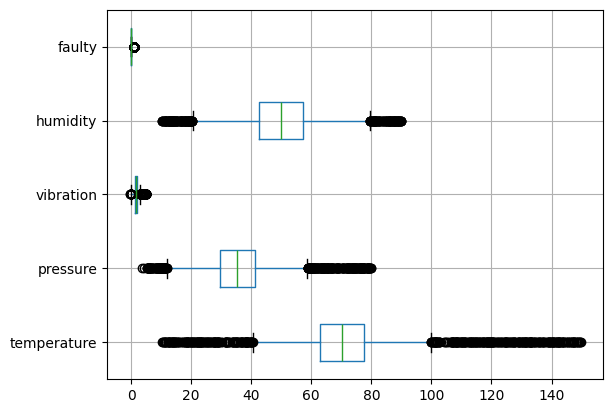

In [16]:
# code here
num_columns = equipment.select_dtypes('number').columns.to_list()

equipment.boxplot(column = num_columns, vert = False);

💡 **Insight:**

Disetiap komponen variable prediktor numerik, memiliki nilai outlier bawah dan atas.

### 3️⃣ Exploratory Data Analysis (EDA)

#### 🟢<u> Analisis `describe()` </u>

Pada tahapan ini kita akan mencoba untuk melakkan analisis apakah terdapat sebuah hal yang menarik dari hasil fungsi `describe()` untuk masing-masing kelas target

**Kelas Target *Kategori* : 1**

In [18]:
# code here
equipment[equipment['faulty'] == 1].describe()

,temperature,pressure,vibration,humidity,faulty
count,767.000000,767.000000,767.000000,767.000000,767.0
mean,79.880024,42.038679,2.554807,50.466058,1.0
std,40.440541,21.373942,1.430705,22.952035,0.0
min,10.269385,5.165296,0.006115,10.215077,1.0
25%,44.291098,23.675173,1.335757,29.886102,1.0
50%,81.831306,41.766484,2.581200,52.001998,1.0
75%,114.949838,60.299983,3.799604,69.914474,1.0
max,149.690420,79.887734,4.990537,89.984718,1.0


**Kelas Target *Kategori* : 0**

In [19]:
# code here
equipment[equipment['faulty'] == 0].describe()

,temperature,pressure,vibration,humidity,faulty
count,6905.000000,6905.000000,6905.000000,6905.000000,6905.0
mean,69.927484,35.038181,1.507062,49.966645,0.0
std,10.012077,8.010232,0.502891,9.865363,0.0
min,37.587327,3.620798,-0.428188,13.449135,0.0
25%,63.230049,29.711800,1.166388,43.083716,0.0
50%,69.918868,35.049052,1.508354,49.999388,0.0
75%,76.620518,40.410856,1.851252,56.686298,0.0
max,109.262377,62.431284,3.739542,86.113501,0.0


### 4️⃣ Data Pre-Processing

Terdapat 2 hal yang biasanya dilakukan pada tahapan data pre-processing yaitu **Variable Encoding** dan juga **Cross Validation**

#### 🟢 <u> Variable Encoding </u>

Apa yang dimaksud dengan ***Encoding*** dan kenapa harus dilakukan? 

Di Python, data input dan output untuk model *machine learning* harus berbentuk numeric. Ini berarti, ketika data kita mempunyai nilai kategorikal, harus di-*encode* menjadi numerik sebelum dimasukkan ke dalam pemodelan dan evaluasi machine learning.

![](assets/categorical-type.png)


Data kategorikal adalah data yang mengandung nilai label alih-alih nilai numerik. Tipe data kategorikal terbagi menjadi dua, yaitu:

1. Nominal: Tipe kategorikal yang tidak memiliki hubungan antara kategori satu dengan yang lainnya. Contoh: kota (Jakarta, Makassar, Bandung), warna (biru, putih, hitam), hewan (kucing, sapi, ayam).

2. Ordinal: Tipe kategorikal yang memiliki hubungan bertingkat. Contoh: tingkat pendidikan (s1, s2, s3), tingkat kepuasan (kecewa, netral, puas), pengalaman kerja (junior, mid, senior).


📢 **Diskusi:** 

Dari variable yang kita miliki, manakah yang termasuk ordinal encoding dan nominal encoding?

In [21]:
equipment.select_dtypes("category").head()

,equipment,location
0,Turbine,Atlanta
1,Compressor,Chicago
2,Turbine,San Francisco
3,Pump,Atlanta
4,Pump,New York


**Jawab:**

* Nominal : Semua variable categorical nominal (`equipment` & `location`)
* Ordinal : Tidak ada variable categorical yang termasuk dalam ordinal

#### 🟢 <u> Nominal Encoding di Python </u>

Implementasi nominal encoding memiliki perbedaan dengan ordinal encoding, apabila dalam ordinal encoding label kategorikal di ganti dengan nilai yang memiliki bobot, maka dalam nominal encoding yang akan di cek adalah kemunculan nilai dalam suatu baris. 

Berikut adalah gambaran nominal encoding: 

![x](assets/one_hot-dummy.png)

Implementasi pada Python:

- Dilakukan dengan menggunakan fungsi `pd.get_dummies()`
- **One hot encoding** = mengubah kolom kategorik menjadi kolom-kolom baru dari setiap kategori yang berisi nilai 0 dan 1 
- **Dummy variable** =  mengubah kolom kategorik menjadi kolom-kolom baru yang terdiri dari **k-1 kategori**, berisi nilai 0 dan 1. Kategori yang tidak menjadi kolom, akan menjadi kondisi basis. Untuk membuat dummy variable, tambahkan parameter `drop_first=True`

In [22]:
cat_columns

['equipment', 'location']

In [23]:
equip_dummy = pd.get_dummies(data=equipment, 
                             columns=cat_columns, 
                             drop_first=True, 
                             dtype='int')

equip_dummy.head()

,temperature,pressure,vibration,humidity,faulty,equipment_Pump,equipment_Turbine,location_Chicago,location_Houston,location_New York,location_San Francisco
0,58.180180,25.029278,0.606516,45.694907,0.0,0,1,0,0,0,0
1,75.740712,22.954018,2.338095,41.867407,0.0,0,0,1,0,0,0
2,71.358594,27.276830,1.389198,58.954409,0.0,0,1,0,0,0,1
3,71.616985,32.242921,1.770690,40.565138,0.0,1,0,0,0,0,0
4,66.506832,45.197471,0.345398,43.253795,0.0,1,0,0,0,1,0


#### 🟢 <u> Cross Validation </u>

*Cross Validation* adalah metode yang kita gunakan untuk mengetahui seberapa baik performa model kita memprediksi terhadap data baru.

Lantas, bagaimana cara mengetahui apakah model yang kita buat telah baik dalam memprediksi data baru? Di sinilah mengapa kita melakukan Train-test splitting. Kita membagi data kita menjadi 2 kelompok, yaitu data `train` dan `test`.

<img src="assets/test-trainn.png" width="600"/>

- Data `train`: Data yang model gunakan untuk training.

- Data `test`: Data untuk evaluasi model (Untuk melihat seberapa baik model memprediksi terhadap data yang tidak digunakan untuk training)

📌 **Analogi sederhana**

- Seorang siswa dapat dikatakan pintar ketika dapat menjawab benar soal-soal ujian yang tidak pernah dikerjakannya pada soal-soal latihan untuk persiapan ujian.
- Data `train` diibaratkan soal latihan, dan data `test` diibaratkan soal ujian. Adapun `model` kita diibaratkan sebagai siswa.


Kita dapat menggunakan fungsi `train_test_split` dengan beberapa parameter sebagai berikut.
- `arrays`: dataframe yang kita gunakan (dipisah , untuk yang prediktor dan target variable)
- `test_size`: jumlah persentase dari data yang akan digunakan sebagai data test
- `train_size`: jumlah persentase dari data yang akan digunakan sebagai data test (akan otomatis terisi jika `test_size` diberi nilai)
- `random_state`: nilai random number generator (RNG). Jika kita memasukkan suatu nilai integer untuk parameter ini maka akan menghasilkan hasil yang sama untuk nilai yang sama. Jika kita mengubah nilainya, maka hasilnya akan berbeda.

> **💡 NOTES**: Biasanya data dibagi menjadi 80:20 atau 70:30 (train size:test size). Porsi yang besar selalu digunakan untuk training

In [ ]:
from sklearn.model_selection import train_test_split

# memisahkan prediktor dan target
# target
y = equip_dummy['faulty']

# all predictor except the target
X = equip_dummy.drop(columns='faulty')

# Cross validation
X_train, X_test, y_train, y_test = train_test_split(X, 
                                                    y,
                                                    test_size= 0.2,
                                                    random_state=123)

❓ **Mengapa kita perlu mengunci sifat random yang ada?**

- Agar kita mendapatkan hasil antara data train dan data test yang sama 
- Ketika kita ingin melakukan adjustment/tunning pada model yang sudah ada, data yang akan dimasukan kembali ke model tersebut sama dengan model yang sebelumnya. Sehingga kita bisa melakukan komparasi yang apple to apple terhadap kedua model tersebut.

#### 🟢 <u> Balancing Data </u>

**Cek Proporsi Kelas Target**

Setelah melakukan cross validation, kita perlu memastikan bahwa proporsi kelas target kita sudah seimbang atau belum.

❓ **Mengapa kita harus mencari tau proporsi targetnya seimbang/tidak?**

- Proporsi yang seimbang penting untuk agar model dapat mempelajari karakteristik kelas positif maupun negatif secara seimbang
- Dalam kata lain, tidak hanya belajar dari satu kelas saja. Hal ini mencegah model dari *hanya baik memprediksi 1 kelas saja*

Dalam melakukan pengecekan, pandas sudah menyediakan sebuah fungsi `crosstab()`. Pada fungsi tersebut akan di-isi dengan 3 parameter yaitu

- `index`: parameter ini akan di-isi dengan target data train kita
- `columns`: parameter ini akan di-isi dengan target variable
- `normalize`: dapat di-isi dengan True untuk menunjukan hasil dalam bentuk persentase.

In [25]:
# Code here
pd.crosstab(
    index = y_train,
    columns = 'freq'
)

col_0,freq
faulty,
0.0,5517
1.0,620


In [28]:
pd.crosstab(
    index = y_train,
    columns = 'freq',
    normalize=True
).round(3)

col_0,freq
faulty,
0.0,0.899
1.0,0.101


Proporsi yang imbalance sebenarnya cukup subjektif dan tidak ada aturan bakunya. Akan tetapi ketika proporsinya targetnya *90%:10%* atau *95%:5%*, target variable tersebut akan dianggap tidak seimbang.

**Action Plan ketika datanya imbalance:**

- Tambah data real -> memerlukan waktu
- Metode *downSampling* -> Membuang observasi dari kelas mayoritas, sehingga seimbang.
- Metode *upSampling* -> Duplikasi observasi dari kelas minoritas, sehingga seimbang.

![](assets/downsample_upsample.png)

✏️ **Note:** 

- *Data yang cukup banyak* dalam artian frekuensi datanya cukup banyak untuk kelas minoritas. Ini bisa dilihat dari proporsi kelas target. Jika ternyata terdapat 1000 data namun ternyata 800 kelas mayoritas, dan 200 kelas minoritas, setelah downsampling jadi ada 400 data, datanya masih cukup sedikit. Usahakan jumlah data minoritas setidaknya 300 observasi.
- Bila data masih terlalu sedikit dan tidak ingin melakukan upsampling, berarti kita harus menambah data.

🔻 **Kita akan menggunakan upsample karena data minoritas kurang dari 1000 observasi**

- Metode OverSample sudah disediakan dari submodule `RandomOverSampler` dari module `imbalanced-learn`. Pada module tersebut terdapat fungsi `RandomOverSampler()` yang diperuntukkan untuk melakukan duplikasi pada kelas minoritas hingga memiliki frekuensi yang sama dengan kelas mayoritas.
- Selanjutnya, gunakan fungsi `fit_resample()` untuk implementasi ke data equipment.

✏️ **Note:** Untuk downsample kita dapat import submodule [`RandomUnderSampler`](https://imbalanced-learn.org/stable/references/generated/imblearn.under_sampling.RandomUnderSampler.html)

In [ ]:
# import library
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler # digunakan untuk downsample

# ambil beberapa sample data mayoritas
oversampler = RandomOverSampler(random_state=123)

# Implementasi
X_train_up, y_train_up = oversampler.fit_resample(X_train, y_train)

Check proporsi kelas

In [32]:
# code here
pd.crosstab(
    index = y_train_up,
    columns = 'freq',
    normalize=True
).round(3)

col_0,freq
faulty,
0.0,0.5
1.0,0.5


💡 **Insight:**

### 5️⃣ Model Fitting

Untuk membuat model decision tree, kita dapat menggunakan fungsi `DecisionTreeClassifier()` yang termasuk dalam `sklearn.tree` module.

Pada fungsi tersebut, terdapat parameter yang dapat diisikan yaitu:
- `random_state =`  Parameter ini untuk mengunci sifat random pemasukan data

Seperti biasa, ketika ingin melakukan fitting model, maka kita gunakan `.fit()`. Pada fungsi `.fit()` kita dapat memasukkan informasi prediktor dan target variabel kita.

#### 🟢 Model Initialization & Fitting

In [33]:
# import library
from sklearn.tree import DecisionTreeClassifier

# model initialization
dt_equipment = DecisionTreeClassifier(random_state=123)

# fit model
dt_equipment.fit(X_train_up, y_train_up)

DecisionTreeClassifier(random_state=123)

#### 🟡 [Optional] Visualization & Interpretation 

Yang menarik dari decision tree yaitu, kita memperoleh **rule-based** yang dapat kita interpretasikan. Rule based ini dapat kita visualisasikan sebagai pohon keputusan. Untuk memvisualisasikannya, kita dapat menggunakan fungsi `plot_tree` dari `matplotlib` package.

In [34]:
import matplotlib.pyplot as plt
from sklearn.tree import plot_tree

# visualization
plt.figure(figsize=(10,10))
plot_tree(dt_equipment, 
          feature_names=X_train.columns, 
          filled=True, 
          rounded=True);

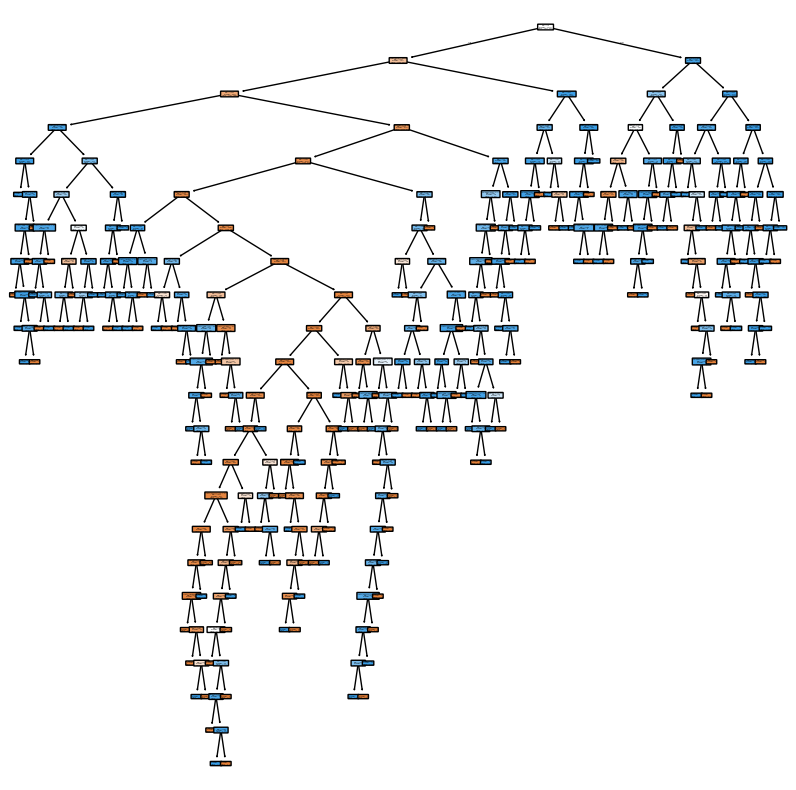

In [35]:
# menampilkan plot
plt.show()

Kita juga dapat mengeksport rules yang ada pada model decision tree yang sudah dibuat dengan bantuan function `export_text()`

In [36]:
from sklearn.tree import export_text
tree_text = export_text(dt_equipment, feature_names=X_train.columns.to_list())
print(tree_text)

|--- vibration <= 2.45
|   |--- temperature <= 96.48
|   |   |--- temperature <= 46.36
|   |   |   |--- temperature <= 40.59
|   |   |   |   |--- temperature <= 37.35
|   |   |   |   |   |--- class: 1.0
|   |   |   |   |--- temperature >  37.35
|   |   |   |   |   |--- vibration <= 1.45
|   |   |   |   |   |   |--- location_New York <= 0.50
|   |   |   |   |   |   |   |--- temperature <= 37.77
|   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |   |--- temperature >  37.77
|   |   |   |   |   |   |   |   |--- equipment_Turbine <= 0.50
|   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |--- equipment_Turbine >  0.50
|   |   |   |   |   |   |   |   |   |--- humidity <= 34.64
|   |   |   |   |   |   |   |   |   |   |--- class: 1.0
|   |   |   |   |   |   |   |   |   |--- humidity >  34.64
|   |   |   |   |   |   |   |   |   |   |--- class: 0.0
|   |   |   |   |   |   |--- location_New York >  0.50
|   |   |   |   |   |   |   |--- class

💡 **Insight :** Salah satu karakteristik dari `Decision Tree` adalah model ini sangat detail dalam membuat pohonnya, bahkan bisa sampai ada 1 observasi pada leaf node nya. 
Hal ini membuat decision tree justru *menghafal* pola di data train, dan membuat aturan yang terlalu kompleks, bukan *mempelajari* pola tersebut. Alhasil model menjadi kurang general untuk diaplikasikan ke data yang bukan data train, sehingga cenderung overfit. 

Maka dari itu, ada suatu metode yang dapat digunakan untuk melakukan pemotongan pada tree yang terbentuk. Pemotongan/pencegahan cabang pohon itu dinamakan **Pruning**

#### 🌳🪓 Model Tuning - Pruning and Tree-Size 🌳🪓

Pruning terbagi menjadi 2 cara:

* **Pre-Pruning**: Terlebih dahulu memasang parameter sebelum model dihasilkan. Metode ini kurang disarankan karena kita belum memiliki informasi tentang parameter apa yang sebaiknya kita atur (harus menduga).

* **Post-Pruning**: Pruning setelah kita mendapatkan model yang lengkap atau kompleks, lalu menentukan seberapa jauh kita akan memangkas cabang pada Decision Tree.

Pruning yang akan kita lakukan akan diimplementasikan pada saat pembentukan model Decision Tree dengan menambahkan beberapa parameter:

* **max_depth**: kedalaman maksimum pohon untuk membuat cabang
* **min_samples_split**: Jumlah minimal observasi di interior node sebelum pemisahan. Bila tidak terpenuhi, tidak dilakukan percabangan. 
* **min_samples_leaf**: Jumlah minimal observasi di terminal node. Bila tidak terpenuhi, tidak dilakukan percabangan. 

Sekarang kita akan coba melakukan hyperparameter tuning pada model sebelumnya dengan mengatur:
- max_depth : 3
- min_samples_split : 10
- min_samples_leaf : 5

**Notes:**

Untuk membuat model tree yang lebih sederhana, kita dapat memperbesar nilai `min_sample_split` dan `min_samples_leaf`

In [ ]:
# code here
dt_equipment_tuning = DecisionTreeClassifier(max_depth = 3,
                                      min_samples_split = 15,
                                      min_samples_leaf=10,
                                      random_state = 123,
                                      criterion='entropy')

# fitting
dt_equipment_tuning.fit(X_train_up, y_train_up)

DecisionTreeClassifier(max_depth=3, min_samples_leaf=10, min_samples_split=15,
                       random_state=123)

In [40]:
# visualization
plt.figure(figsize=(15,15), dpi=150)
plot_tree(dt_equipment_tuning, 
          feature_names=X_train.columns, 
          class_names=True,
          filled=True, 
          rounded=True);

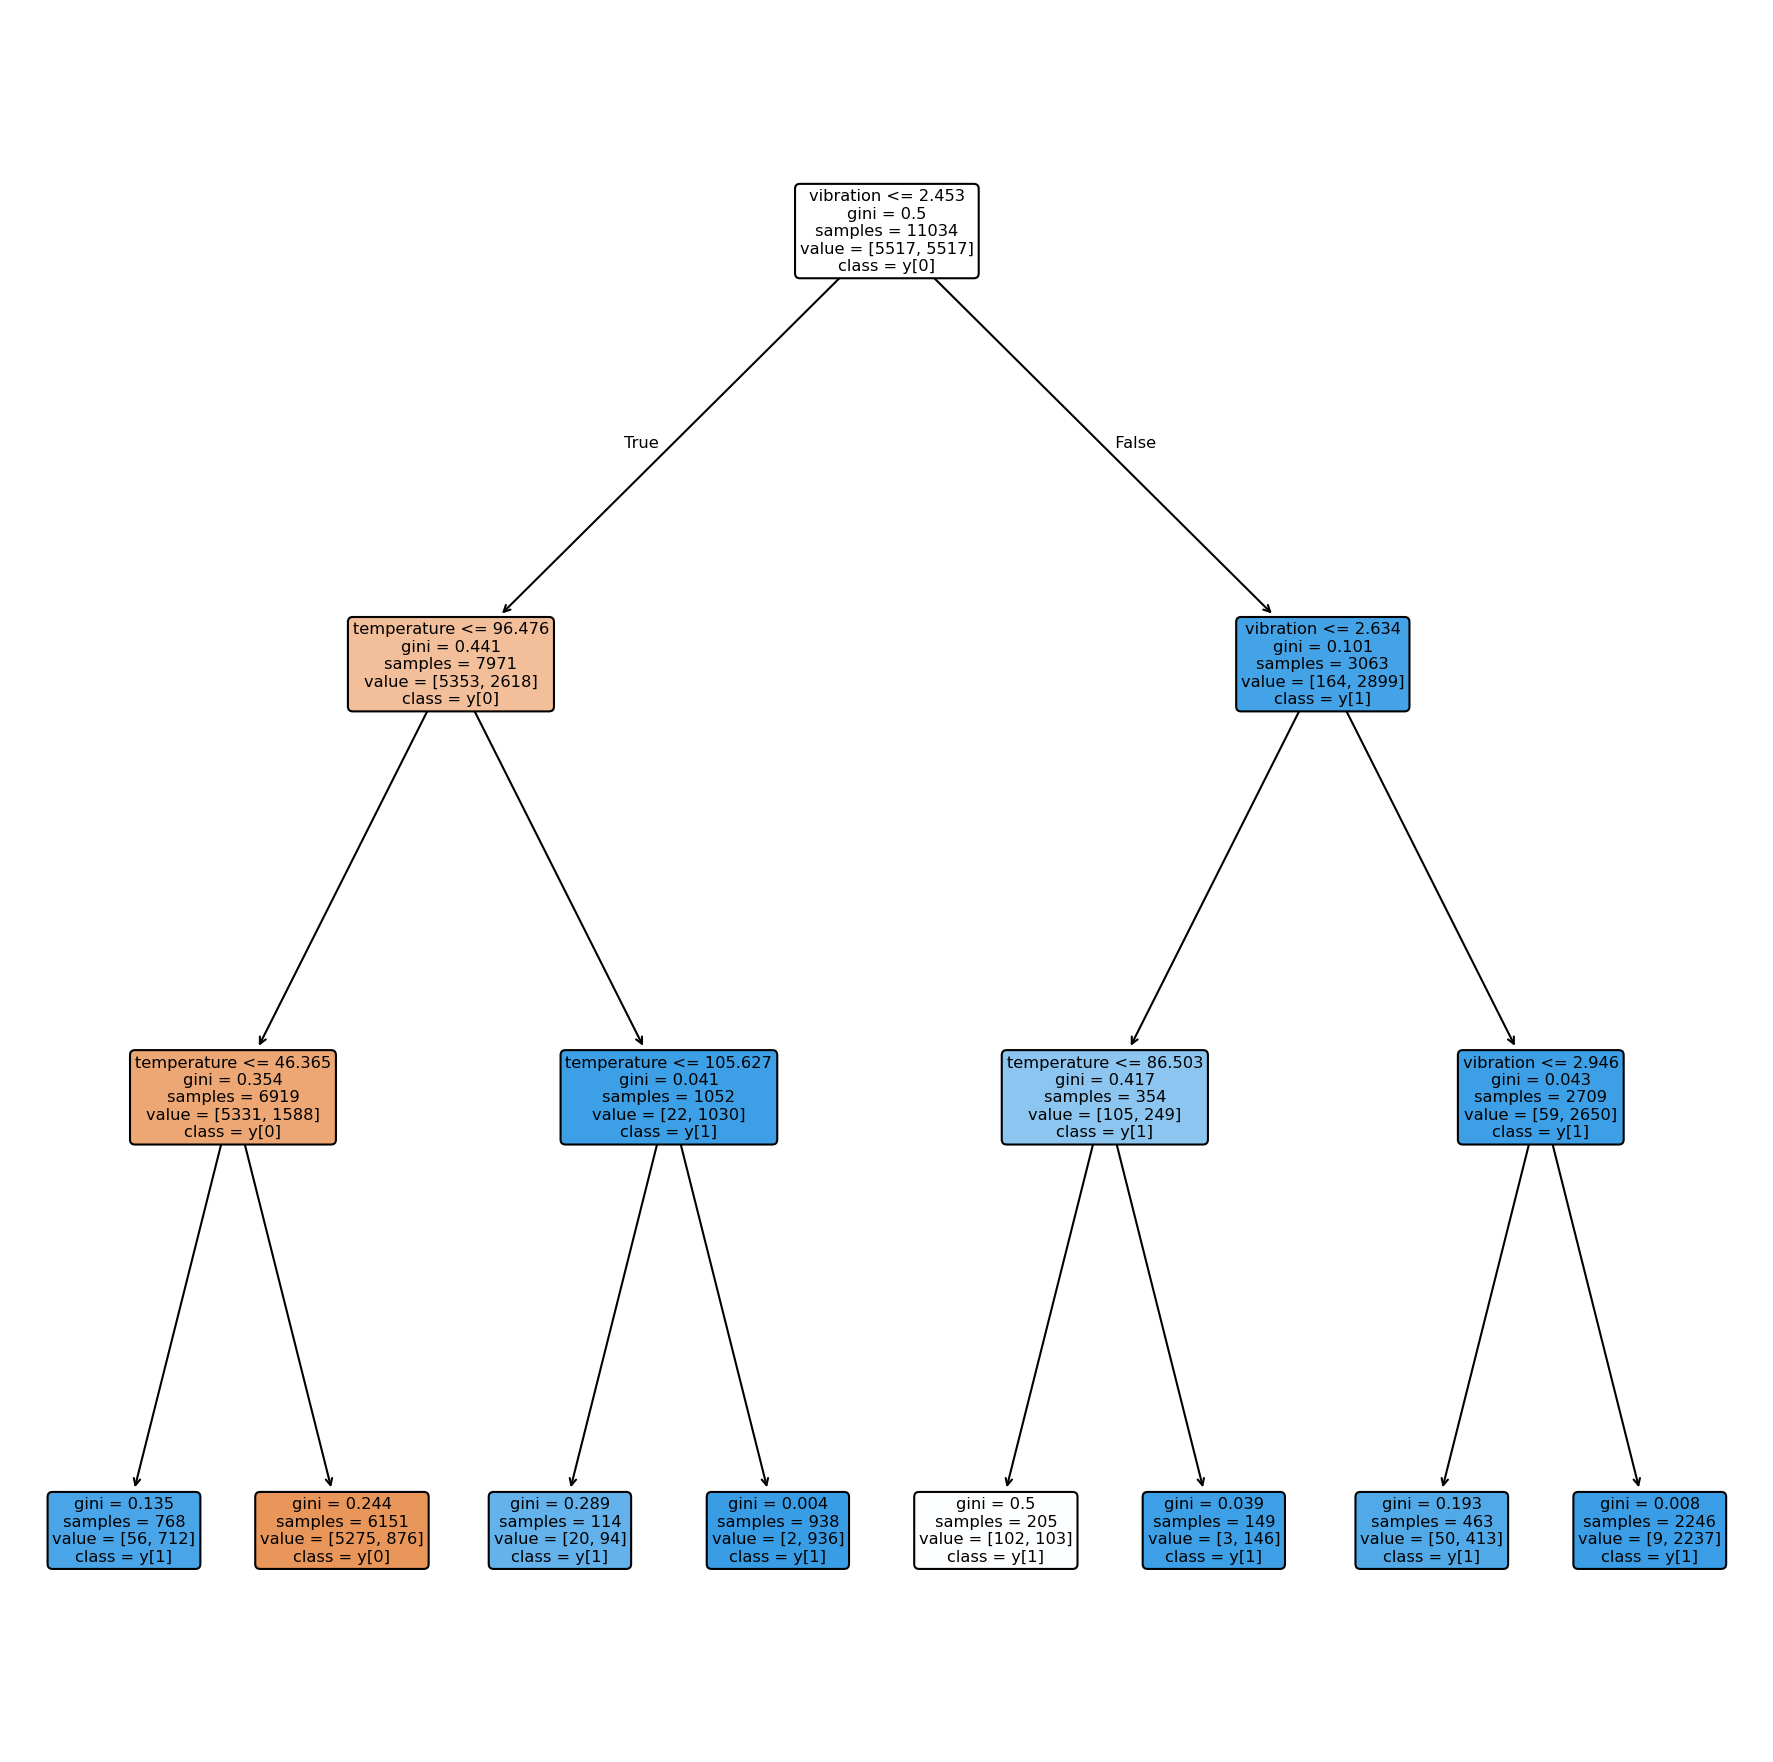

In [41]:
# menampilkan plot DT
plt.show()

In [42]:
# Export text
tree_text = export_text(dt_equipment_tuning, feature_names=X_train.columns.to_list())
print(tree_text)

|--- vibration <= 2.45
|   |--- temperature <= 96.48
|   |   |--- temperature <= 46.36
|   |   |   |--- class: 1.0
|   |   |--- temperature >  46.36
|   |   |   |--- class: 0.0
|   |--- temperature >  96.48
|   |   |--- temperature <= 105.63
|   |   |   |--- class: 1.0
|   |   |--- temperature >  105.63
|   |   |   |--- class: 1.0
|--- vibration >  2.45
|   |--- vibration <= 2.63
|   |   |--- temperature <= 86.50
|   |   |   |--- class: 1.0
|   |   |--- temperature >  86.50
|   |   |   |--- class: 1.0
|   |--- vibration >  2.63
|   |   |--- vibration <= 2.95
|   |   |   |--- class: 1.0
|   |   |--- vibration >  2.95
|   |   |   |--- class: 1.0



#### 🟢 Interpretasi model

Interpretasi dari rules yang terbuat akan sangat berguna untuk orang teknis menetahui alasan mengapa suatu data diklasifikasikan pada kelas tertentu.

Rules yang terbentuk adalah sebagai berikut:
- ...
- ...

### 6️⃣ Model Predict

Setelah melakukan pembuatan model dan melakukan pemotongan pada pohon, mari kita lakukan prediksi terhadap data test yang ada.


1. Predict dengan `dt_equipment`

In [43]:
# model dt equipment
pred_dt_equipment = dt_equipment.predict(X_test)

In [44]:
pred_dt_equipment

array([0., 0., 0., ..., 0., 0., 0.], shape=(1535,))

2. Predict dengan `dt_equipment_tuning`

In [45]:
# model dt equipment tuning
pred_dt_equipment_tuning = dt_equipment_tuning.predict(X_test)
pred_dt_equipment_tuning

array([0., 0., 0., ..., 0., 0., 0.], shape=(1535,))

In [46]:
y_test

5431    0.0
6565    0.0
6406    0.0
7154    0.0
7532    0.0
       ... 
7011    0.0
5946    0.0
7304    0.0
1917    0.0
2591    0.0
Name: faulty, Length: 1535, dtype: float64

### 7️⃣ Model Evaluation

Setelah dilakukan prediksi menggunakan model, masih ada saja prediksi yang salah. Pada klasifikasi, kita mengevaluasi model berdasarkan **confusion matrix**:

Langkah berikutnya setelah dilakukan prediksi menggunakan model adalah melakukan evaluasi. Pada klasifikasi, kita mengevaluasi model berdasarkan **confusion matrix**.

- Penentuan kelas:
  + kelas positif: kelas yang menjadi concern/amatan
  + kelas negatif: kelas yang tidak menjadi concern/amatan

- Contoh kasus: 
  + Machine learning untuk deteksi pasien cancer:
    * kelas positif: terdeteksi cancer
    * kelas negatif: terdeteksi sehat

- Isi dari Confusion Matrix:

  * True Positive (TP): diprediksi positif dan benar (prediksi positif; aktual positif)
  * True Negative (TN): diprediksi negatif dan benar (prediksi negatif; aktual negatif) 
  * False Positive (FP): diprediksi positif namun salah (prediksi positif; aktual negatif)
  * False Negative (FN): diprediksi negatif namun salah (prediksi negatif; aktual positif)
    
![](assets/tnfp.PNG)

**KONDISI DATA EQUIPMENT**

- **Positive Class (+)** : Mesin Rusak
- **Negative Class (-)** : Mesin Tidak Rusak

- **TP:** Actual mesin rusak, prediksi mesin rusak
- **TN:** Actual mesin tidak rusak, prediksi mesin rusak
- **FP:** Actual mesin tidak rusak, prediksi rusak
- **FN:** Actual mesin rusak, prediksi mesin tidak rusak

1. Confusion Matrix `dt_equipment`

In [47]:
# confusion matrix
pd.crosstab(index = pred_dt_equipment, 
            columns = y_test,
            rownames=['Prediksi'],
            colnames=['Actual'])

Actual,0.0,1.0
Prediksi,,
0.0,1366,23
1.0,22,124


In [49]:
TP_original = 124
TN_original = 1366
FP_original = 22
FN_original = 23

2. Confusion Matrix `dt_equipment_tuning`

In [48]:
# confusion matrix
pd.crosstab(index = pred_dt_equipment_tuning, 
            columns = y_test,
            rownames=['Prediksi'],
            colnames=['Actual'])

Actual,0.0,1.0
Prediksi,,
0.0,1329,22
1.0,59,125


In [50]:
TP_tuning = 125
TN_tuning = 1329
FP_tuning = 59
FN_tuning = 22

Metrics performa model: **Accuracy, Sensitivity/Recall, Precision**

- **Accuracy**: seberapa tepat model kita memprediksi kelas target (secara global)   
- **Sensitivity**/ **Recall**: ukuran kebaikan model terhadap kelas `positif`    
- Pos Pred Value/**Precision**: seberapa presisi model memprediksi kelas positif  

#### 🟢 <u> Accuracy </u>

Seberapa banyak yang benar diprediksi dari keseluruhan data (positif maupun negatif).

$$\frac{TP+TN}{TOTAL}$$

1. Accuracy `dt_equipment`

In [52]:
# code here
(TP_original+TN_original)/(TP_original+TN_original+FP_original+FN_original)

0.9706840390879479

2. Accuracy `dt_equipment_tuning`

In [53]:
# code here
(TP_tuning+TN_tuning)/(TP_tuning+TN_tuning+FP_tuning+FN_tuning)

0.9472312703583062

📌 Note: tidak ada batasan mutlak berapa akurasi yang dianggap akurat (sudah baik):

* dikembalikan ke kebutuhan bisnis masing-masing. 
  + Misalkan medis untuk diagnosis penyakit perlu akurasi yang sangat tinggi
  + Sementara di bidang pemasaran, akurasi bisa saja tidak perlu setinggi itu

📌 Nilai akurasi digunakan ketika:

* kelas target sama penting
* data balance

Secara general, nilai akurasi, makin mendekati satu, makin baik

Ada kondisi ketika **accuracy bukanlah metrics terpenting**. Umumnya ketika:

- kita mementingkan salah satu kelas (misal, kelas target/positif)
- data kita imbalance

Saat kita mementingkan kelas tertentu, maka kita dapat memilih antara menggunakan metrics Recall / Precision: 

#### 🟢 <u> Sensitivity/Recall </u>

Seberapa banyak yang **benar diprediksi positif**, dari yang **reality**-nya (aktualnya) positif.

$$\frac{TP}{(TP+FN)}$$

1. Recall `dt_equipment`

In [54]:
# code here
TP_original/(TP_original+FN_original)

0.8435374149659864

2. Recall `dt_equipment_tuning`

In [55]:
# code here
TP_tuning/(TP_tuning+FN_tuning)

0.8503401360544217

### 🟢 <u> Precision/Pos Pred Value </u>

Seberapa banyak yang **benar diprediksi positif**, dari yang di**prediksi** positif. 

$$\frac{TP}{(TP+FP)}$$

1. Precision `dt_equipment`

In [56]:
# code here
TP_original/(TP_original+FP_original)

0.8493150684931506

2. Precision `dt_equipment_tuning`

In [57]:
# code here
TP_tuning/(TP_tuning+FP_tuning)

0.6793478260869565

🟡 **Cara Cepat:**

1. Evaluation dengan `dt_equipment`

In [58]:
print(f'Accuracy score: {accuracy_score(y_test, pred_dt_equipment)}')
print(f'Recall score: {recall_score(y_test, pred_dt_equipment)}')
print(f'Precision score: {precision_score(y_test, pred_dt_equipment)}')

Accuracy score: 0.9706840390879479
Recall score: 0.8435374149659864
Precision score: 0.8493150684931506


2. Evaluation dengan `dt_equipment_tuning`

In [59]:
print(f'Accuracy score: {accuracy_score(y_test, pred_dt_equipment_tuning)}')
print(f'Recall score: {recall_score(y_test, pred_dt_equipment_tuning)}')
print(f'Precision score: {precision_score(y_test, pred_dt_equipment_tuning)}')

Accuracy score: 0.9472312703583062
Recall score: 0.8503401360544217
Precision score: 0.6793478260869565


✍️ **Metric Evaluation:** Recall

✍️ **Model Final:** `dt_equipment`



Tahapan pemilihan recall/precision pada evaluasi model:

1. Definisikan kelas positif
2. Pahami resiko paling concerning dari kesalahan prediksi (lihat dari FN dan FPnya)
3. Pilih metric recall atau precision

#### 🟢 Bias-Variance Tradeoff

Dalam pembuatan model, model berusaha mempelajari pola yang terdapat dalam data sehingga dihasilkan suatu aturan yang dapat memprediksi kelas/nilai target dengan tepat. Untuk masing-masing model machine learning, terdapat karakteristik yang disebut *bias* dan *variance*.

* **bias**: perbedaan antara hasil prediksi dengan nilai aktual
* **variance**: variasi hasil prediksi yang mungkin muncul pada titik data tertentu

![](assets/underfitting_overfitting.png)

Kekurangan dari Decision Tree adalah kecenderungannya untuk overfitting. Hal ini terjadi karena Decision tree mampu membagi-bagi data hingga amat detail (bahkan hingga dalam leaf node hanya terdapat 1 observasi). Hal ini membuat decision tree justru *menghafal* pola di data train, dan membuat aturan yang terlalu kompleks, bukan *mempelajari* pola tersebut. Alhasil model menjadi kurang general untuk diaplikasikan ke data yang bukan data train, sehingga cenderung overfit. 

**Kondisi Model:**

- **Overfitting**: model baik di data train, namun amat buruk di data test $\rightarrow$ tidak diinginkan
  - karena model terlalu kompleks (misal, decision tree -> tree prunning)
  - 10 - 15% perbedaanya pada metriks data train dan data test
    Contoh: Recall di data train 80% dan Recall di data test 70%
- **Underfitting**: model buruk di data train maupun di data test $\rightarrow$ tidak diinginkan
  - Contoh: Recall di data train 50% dan Recall di data test 40%
  - karena model terlalu sederhana (misal, linear/log regression -> ganti model)
- **Just Right**: model baik di data train, dan pada data test menurun sedikit (selisih < 0.1) $\rightarrow$ yg kita inginkan
  - 10 - 15% perbedaanya pada metriks data train dan data test

Untuk melihat apakah model yang kita miliki adalah model yang cukup baik (dalam hal ini tidak overfit maupun underfit) kita akan coba mengeceknya dengan melakukan **evaluasi pada data train** dan membandingkannya dengan **evaluasi pada data test**:

1. Model Predict untuk Data Train dan Data Test

**Data Train**

In [60]:
# code here
pred_dt_equipment_train = dt_equipment.predict(X_train_up)
pred_dt_equipment_train

array([0., 0., 0., ..., 1., 1., 1.], shape=(11034,))

**Data Test**

In [61]:
# code here
pred_dt_equipment

array([0., 0., 0., ..., 0., 0., 0.], shape=(1535,))

2. Model Evaluation untuk Data Train dan Data Test

**Data Train**

In [62]:
# code here
print(f'Accuracy score: {accuracy_score(y_train_up, pred_dt_equipment_train)}')
print(f'Recall score: {recall_score(y_train_up, pred_dt_equipment_train)}')
print(f'Precision score: {precision_score(y_train_up, pred_dt_equipment_train)}')

Accuracy score: 1.0
Recall score: 1.0
Precision score: 1.0


**Data Test**

In [63]:
# code here
print(f'Accuracy score: {accuracy_score(y_test, pred_dt_equipment)}')
print(f'Recall score: {recall_score(y_test, pred_dt_equipment)}')
print(f'Precision score: {precision_score(y_test, pred_dt_equipment)}')

Accuracy score: 0.9706840390879479
Recall score: 0.8435374149659864
Precision score: 0.8493150684931506


**END OF DAY 1**

---

**START OF DAY 2**

# Ensemble Methods

Ensemble methods adalah metode pembelajaran yang menggabungkan prediksi dari beberapa model machine learning menjadi 1 prediksi tunggal. 

## Wisdom of the Crowd

Salah satu cara untuk menekan bias dan variance sekaligus adalah dengan **menggabungkan prediksi dari beberapa model menjadi 1 prediksi tunggal**. Gabungan beberapa model machine learning ini disebut dengan **Ensemble Method**. Ensemble method bertujuan untuk meningkatkan performa model dalam memprediksi. Salah satu contoh ensemble method yang merupakan pengembangan dari decision tree adalah **Random Forest**.

<div style="background-color:#d18b49; text-align: center; margin: 0 auto; color: black;">

# 🌳🌳Random Forest🌳🌳

</div>

## Memahami Random Forest

Random Forest adalah salah satu jenis Ensemble Method. Random Forest melakukan prediksi dengan membuat **banyak Decision Tree**. Masing-masing Decision Tree memiliki karakteristik masing-masing dan tidak saling berhubungan satu sama lain. Random Forest kemudian melakukan prediksi untuk masing-masing decision tree, kemudian dari sekian banyak hasil prediksi tersebut dilakukan voting. Kelas dengan jumlah terbanyak akan menjadi hasil prediksi final. Random Forest memanfaatkan konsep bernama **Bagging: Bootstrap and Aggregation**. Berikut adalah proses yang terjadi:

1. Membuat data dengan random sampling dari data yang ada dan mengizinkan adanya duplikat (**Bootstrap sampling**)
2. Membuat decision tree dari masing-masing data hasil bootstrap sampling, digunakan prediktor sebanyak `mtry` yang juga dipilih secara random
3. Melakukan prediksi data baru untuk setiap decision tree
4. Melakukan majority voting untuk menentukan hasil prediksi final (**Aggregation**)

![](assets/random_forest.PNG)

**Kelebihan**:
- Mereduksi bias sekaligus variance dari decision tree
- Robust untuk prediction
- Automatic Feature Selection pemilihan prediktor secara otomatis & random pada pembuatan decision tree
- Out-of-Bag error pengganti evaluasi model ke data test

## Basic Implementation

Dengan menggunakan kasus yang sama, kita akan melakukan training menggunakan `RandomForestClassifier` dengan parameter default (membuat 100 pohon)

Pada fungsi tersebut nantinya kita akan mengisinya dengan beberapa parameter, seperti

- `oob_score =`: apakah akan menggunakan out-of-bag samples untuk evaluasi atau tidak
- `n_estimators =`: banyaknya tree yang akan dibuat

Selain dari 2 parameter tersebut, terdapat parameter-parameter dari Decision Tree yang sudah kita gunakan.

* `max_depth`: kedalaman maksimum pohon untuk membuat cabang
* `min_samples_split`: Jumlah minimum sampel yang diperlukan untuk memisahkan internal/interior node. Bila tidak terpenuhi, tidak dilakukan percabangan. 
* `min_samples_leaf`: Jumlah minimum sampel yang diperlukan untuk berada pada leaf node. Pada setiap percabangan akan dihitung jumlah sampel minimum pada cabang kanan atau kiri sebanyak nilai min_sample_leaf.

### 5️⃣ Model Fitting

In [ ]:
# import library
from sklearn.ensemble import RandomForestClassifier

# model intialize 
rf_equipment = RandomForestClassifier(random_state=100, 
                                   oob_score = True, 
                                   n_estimators= 100,
                                   max_depth=40,
                                   min_samples_split=10,
                                   min_samples_leaf=5)

In [ ]:
# model training


### 6️⃣ Model Predict

**Data Train**

In [ ]:
# code here
pred_train_rf = 

**Data Test**

In [ ]:
# code here
pred_test_rf = 

### 7️⃣ Model Evaluation

**Data Train**

In [ ]:
# code here
print(f'Recall score: {recall_score(___, ___)}')

Recall score: 1.0


**Data Test**

In [ ]:
# code here
print(f'Recall score: {recall_score(___, ___)}')
print(f'Precision score: {precision_score(___, ___)}')
print(f'Accuracy score: {accuracy_score(___, ___)}')

#### 🟢 Out of Bag Error

Meskipun sebelumnya kita melakukan splitting data dan dapat mengevaluasi data menggunakan data_test, sebenarnya kita **tidak perlu melakukan cross-validation** saat menggunakan random forest. Hal ini karena dari hasil **boostrap sampling**, terdapat data-data yang tidak digunakan dalam pembuatan random forest. Data-data tersebut adalah **out-of-bag data** dan dianggap sebagai *data test* oleh model. Model akan melakukan prediksi dengan data tersebut dan menghitung akurasi model yang dihasilkan. Akurasi tersebut disebut sebagai **out-of-bag score**.

In [ ]:
# cek oob_score


### 8️⃣ Variable Importance

Yang menarik dari random forest, walaupun model yang kita miliki sangat out of the box, kita dapat mengetahui variabel yang dianggap penting. Untuk mengetahui tingkat kepentingan dari suatu variabel kita dapat menggunakan tingkat impurity suatu variabel.

Semakin tinggi, semakin penting fitur tersebut. Pentingnya suatu fitur dihitung sebagai pengurangan total (dinormalisasi) dari kriteria yang dibawa oleh fitur tersebut.

Mari kita buat plot di mana kita mendapatkan 10 fitur terpenting. 

In [ ]:
# Mengeluarkan nilai 10 fitur yang dianggap paling penting


In [ ]:
# Visualization
pd.Series(
    rf_equipment.feature_importances_,
    index=X_train_up.columns
    ).sort_values().tail(10).plot.barh(title="Top 10 Feature Importances", xlabel='Gini Importance');

<div style="background-color:#d18b49; text-align: center; margin: 0 auto; color: black;">

# 🎁 [Additional] Logistic Regression 🎁

</div>

Logistic Regression merupakan salah satu metode klasifikasi yang konsepnya hampir mirip dengan regresi linear. Hanya saja, dalam logistic regression tidak menghitung secara spesifik nilai prediksi target variable, namun menghitung **kemungkinan/peluang** pada masing-masing kelas target.

$$ y = b0 + b1x1 + ..... $$

- Linier regresion: y (numerik) -> **-inf, + inf**
- Logistic regression: y (peluang) -> **0, 1**

![](assets/linreg-vs-logreg.png)

📝 Hasil dari regresi logistik dapat digunakan untuk:
- keperluan interpretasi
- keperluan prediksi

❓ Bagaimana regresi logistik bekerja? 

Suatu regresi yang dapat menghasilkan nilai (-inf sd. +inf) yang bisa dikonversi ke bentuk peluang (0 - 1)
  - nilai yg dihasilkan oleh algoritma logistic regression: log of odds
  - nilai dapat dikonversikan antara **log of odds** - **odds** - **peluang**:

<div style="background-color:#ed8ab3; text-align: center; margin: 0 auto; color: black;">

## Logistic Regression - Study Case: Performance Student 

</div>

Bayangkan kita adalah seorang analis performa mahasiswa pada suatu universitas. Pada wisuda tahun ini, kita diminta untuk melakukan analisis prediksi berapa banyak mahasiswa yang lulus dengan predikat cumlaude dan tidak.

### Import data

In [4]:
# code here
honor = pd.read_csv('data_input/sample.csv')

Deskripsi data `honor`:
- `female` : jenis kelamin student (0: male, 1: female)
- `read` : nilai membaca
- `write` : nilai menulis
- `math` : nilai matematika
- `hon` : target variabel, student yang mendapat predikat honor atau tidak, 
  - 0 = student lulus tanpa predikat honors
  - 1 = student lulus dengan predikat honors

### Data Pre-Processing

* **Cek Struktur data**

In [5]:
# code here
honor

,female,read,write,math,hon
0,0,57,52,41,0
1,1,68,59,53,0
2,0,44,33,54,0
3,0,63,44,47,0
4,0,47,52,57,0
...,...,...,...,...,...
195,1,55,59,52,0
196,1,42,46,38,0
197,1,57,41,57,0
198,1,55,62,58,1


* **Cek missing value**

In [6]:
# code here
honor.isnull().sum()

female    0
read      0
write     0
math      0
hon       0
dtype: int64

#### 👑 Model 1 : Berapa peluang siswa memperoleh predikat cumlaude apabila diketahui nilai Matematika?

🎯 Buatlah model honors dengan menggunakan prediktor `math`.

- `target_var`: hon
- `predictor_var`: math

* **Cek target variable**

In [7]:
# code here
honor.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   female  200 non-null    int64
 1   read    200 non-null    int64
 2   write   200 non-null    int64
 3   math    200 non-null    int64
 4   hon     200 non-null    int64
dtypes: int64(5)
memory usage: 7.9 KB


In [9]:
honor[honor['hon']==1].describe()

,female,read,write,math,hon
count,49.000000,49.000000,49.000000,49.000000,49.0
mean,0.653061,60.183673,63.693878,60.938776,1.0
std,0.480929,8.209937,1.970661,7.814005,0.0
min,0.000000,47.000000,61.000000,41.000000,1.0
25%,0.000000,54.000000,62.000000,56.000000,1.0
50%,1.000000,60.000000,63.000000,61.000000,1.0
75%,1.000000,65.000000,65.000000,66.000000,1.0
max,1.000000,76.000000,67.000000,75.000000,1.0


In [10]:
honor[honor['hon']==0].describe()

,female,read,write,math,hon
count,151.000000,151.000000,151.000000,151.000000,151.0
mean,0.509934,49.649007,49.231788,49.953642,0.0
std,0.501565,9.514339,8.146528,8.193768,0.0
min,0.000000,28.000000,31.000000,33.000000,0.0
25%,0.000000,43.000000,44.000000,43.000000,0.0
50%,1.000000,47.000000,52.000000,50.000000,0.0
75%,1.000000,56.000000,57.000000,55.500000,0.0
max,1.000000,76.000000,60.000000,75.000000,0.0


📌 **Modeling dengan Logistic Regression**

0. Melakukan import library

In [12]:
import statsmodels.api as sm

1. Memisahkan variable `target` dengan `predictor`

In [11]:
# X -> Predictor Variable
X = honor['math']

# Y -> Target Variable
Y = honor['hon']

2. Melakukan proses fitting model

<div style="background-color:#90EE90; padding: 3px; border-radius: 5px; border: 2px solid #000000;">
 
```python
# sintaks untuk melakukan fitting model
sm.Logit(target_var, predictor_var).fit()
```

</div>

In [13]:
# fitting model
from sklearn.linear_model import LogisticRegression
model_math = LogisticRegression()
model_math.fit(X.values.reshape(-1, 1), Y)

LogisticRegression()

In [14]:
model_math = sm.Logit(Y, sm.add_constant(X)).fit()
model_math.summary()

Optimization terminated successfully.
         Current function value: 0.417683
         Iterations 7


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    hon   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Wed, 22 Oct 2025   Pseudo R-squ.:                  0.2498
Time:                        10:48:34   Log-Likelihood:                -83.537
converged:                       True   LL-Null:                       -111.36
Covariance Type:            nonrobust   LLR p-value:                 8.718e-14
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -9.7939      1.482     -6.610      0.000     -12.698      -6.890
math           0.1563      0.026      6.105      0.000       0.106       0.207
==============================================================================
"""

3. Menampilkan hasil summary model

#### Log of Odds

In [18]:
#code here
model_math.params

const   -9.793942
math     0.156340
dtype: float64

<div style="background-color:#c21313; padding: 3px; border-radius: 5px; border: 2px solid #000000; color: #ffffff; text-align: center">
 
Silahkan perhatikan output pada bagian **coef**. Nilai tersebut adalah nilai coefficient dari variable predictor yang merupakan nilai **Log of Odds**.

</div>

**💡Range Nilai Log of Odds:** -Inf s/d Inf

#### Odds

4. Interpretasi Koefisien

Seberapa besar pengaruh nilai **math** untuk sesorang mendapatkan predikat **cumlaude (honors)**?

<div class="alert-warning alert" style="text-align: center; margin: 0 auto; color: black;">

Untuk dapat melakukan proses interpretasi, **nilai log of odds harus diubah ke dalam bentuk odds**. 

</div>

* **Interpretasi Coefficient `math`:** log of odds setiap peningkatan 1 nilai di math

In [ ]:
# code here



> **Interpretasi** : Setiap peningkatan 1 nilai `math` akan meningkatkan kemungkinan mahasiswa mendapat honors sebesar ___ KALI dibandingkan tidak mendapat honors

**💡Range Nilai Odds:** 0 - Inf

#### Probability

5. Mengubah dalam bentuk peluang

🧐**Pertanyaan Bisnis:** 

Kevin mengikuti ujian Matematika dan memperoleh nilai **50**. Apakah Kevin akan lulus dengan predikat cumlaude? 

**Jawab:**

🟢 Melihat kembali hasil summary model

In [25]:
# code here
pred_k = -9.793942 + (0.156340 * 50)
expit(pred_k)


0.12164520013305317

Hasil formula model yang diperoleh adalah sebagai berikut :

> $logit(y)= \beta_0 +\beta_1 \times x_1$
>
> $logit(hon) = -9.7939 +0.1563 \times math$

🟢 Melakukan substitusi ke persamaan

In [26]:
# code here
logit_kevin = -9.793942 + (0.156340 * 50)
expit(logit_kevin)


0.12164520013305317

🟢 Transformasi `logit` ke dalam bentuk `peluang`

In [ ]:
from scipy.special import expit

# menggunakan fungsi expit()


<div style="background-color:#c21313; padding: 3px; border-radius: 5px; border: 2px solid #000000; color: #ffffff; text-align: center">
 
Nilai **peluang > 0.5** akan dimasukkan ke dalam kategori **kelas 1 (honors)**.

</div>

**✍️ Kesimpulan:**

**💡Range Nilai Probability:** 0 - 1

#### 👑 Model 2 : Berapa peluang siswa memperoleh predikat cumlaude apabila diketahui gendernya Female/Male?

🎯 Buatlah model honors dengan menggunakan prediktor `female`.

- `target_var`: hon
- `predictor_var`: female

📌 **Modeling dengan Logistic Regression**

1. Memisahkan variable `target` dengan `predictor`


In [27]:
# X -> Predictor Variable
X = honor['female']

# Y -> Target Variable
Y = honor['hon']

2. Melakukan proses fitting model

In [28]:
# fitting model
model_female = sm.Logit(Y, sm.add_constant(X)).fit()

Optimization terminated successfully.
         Current function value: 0.549016
         Iterations 5


3. Menampilkan hasil summary model

In [30]:
# code here
model_female.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    hon   No. Observations:                  200
Model:                          Logit   Df Residuals:                      198
Method:                           MLE   Df Model:                            1
Date:                Wed, 22 Oct 2025   Pseudo R-squ.:                 0.01394
Time:                        11:07:59   Log-Likelihood:                -109.80
converged:                       True   LL-Null:                       -111.36
Covariance Type:            nonrobust   LLR p-value:                   0.07811
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.4709      0.269     -5.469      0.000      -1.998      -0.944
female         0.5928      0.341      1.736      0.083      -0.076       1.262
==============================================================================
"""

4. Interpretasi Koefisien 

Seberapa besar pengaruh nilai **gender female** untuk sesorang mendapatkan predikat **cumlaude (honors)**?

* **Interpretasi Coefficient `female`:** kondisi ketika `female` mendapat `honors`

In [31]:
# code here
math.exp(0.5928)


1.8090466612003744

> **Interpretasi** : Mahasiswi (perempuan) lulus dengan honors ___ KALI lebih mungkin dibandingkan pria.

5. Mengubah dalam bentuk peluang

🧐**Pertanyaan Bisnis:** 

Lita dan Victor adalah siswa di tempat tersebut. Berdasarkan hasil koefisien di atas, siapakah yang lebih berpeluang untuk mendapatkan honors?

> $Formula :$

> $logit(hon) = -1.4709 + 0.5928 \times female$

🟢 Hitung Logit dan Peluang **Lita** mendapatkan honors

In [34]:
# Logit Lita mendapat predikat honors
logit_lita = -1.4709 +(0.5928 * 1)
logit_lita

-0.8781000000000001

In [35]:
# Peluang Lita mendapat predikat honors
expit(logit_lita)

0.29357166024926434

🟢 Hitung Logit dan Peluang **Victor** mendapatkan honors

In [37]:
# Logit Victor mendapat predikat honors
logit_victor  = -1.4709 +(0.5928 * 0)
logit_victor

-1.4709

In [38]:
# Peluang Victor mendapat predikat honors
expit(logit_victor)


0.1868058569430488

**✍️ Kesimpulan:** 

<div class="alert-warning alert" style="text-align: left; margin: 0 auto; color: black;">

**Summary :**

1. Hasil coefficient model adalah berupa **log of odds**. Nilai log of odds tidak dapat di interpretasikan.
2. Agar dapat di interpretasikan nilai log of odds harus diubah kedalam bentuk **odds**
    - Odds = 1 -> sama besar kemungkinannya 
    - Odds < 1 -> lebih tidak mungkin (memiliki pengaruh tidak terlalu tinggi)
    - Odds > 1 -> lebih besar / mungkin (memiliki pengaruh yang tinggi)
3. Untuk memperoleh **hasil klasifikasi**, nilai log of odd harus dimasukkan ke dalam persamaan :
    -  `$logit(y)= \beta_0 +\beta_1 \times x_1$` 
    - kemudian di ubah ke dalam bentuk **probability (peluang)**
4. Nilai peluang > 0.5 akan masuk ke dalam kelas 1.

</div>

### 5️⃣ Model Fitting

Untuk membuat model logistic regression, kita bisa menggunakan fungsi `Logit()` dari package `statsmodels` atau `sm`.

In [55]:
# membuat model
from sklearn.model_selection import train_test_split
X = honor.drop(columns='hon')
y = honor['hon']
X_train, X_test, Y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=123)
model_logit = sm.Logit(Y_train, sm.add_constant(X_train)).fit()

         Current function value: 0.000001
         Iterations: 35


c:\Users\Hanif\anaconda3\lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


📌 **Interpretasi Koefisien** : 


In [45]:
# code here
model_logit.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                           Logit Regression Results                           
==============================================================================
Dep. Variable:                    hon   No. Observations:                  160
Model:                          Logit   Df Residuals:                      155
Method:                           MLE   Df Model:                            4
Date:                Wed, 22 Oct 2025   Pseudo R-squ.:                   1.000
Time:                        11:18:21   Log-Likelihood:            -0.00018482
converged:                      False   LL-Null:                       -85.306
Covariance Type:            nonrobust   LLR p-value:                 7.729e-36
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const      -1021.2219   7376.328     -0.138      0.890   -1.55e+04    1.34e+04
female        -5.7806    175.253     -0.033      0.974    -349.269     337.708
read           0.4099     10.584      0.039      0.969     -20.334      21.153
write         17.1172    123.948      0.138      0.890    -225.816     260.051
math          -0.6492     12.015     -0.054      0.957     -24.198      22.900
==============================================================================

Complete Separation: The results show that there iscomplete separation or perfect prediction.
In this case the Maximum Likelihood Estimator does not exist and the parameters
are not identified.
"""

In [49]:
# code here
from sklearn.metrics import recall_score, precision_score, accuracy_score, roc_auc_score

y_pred = model_logit.predict(sm.add_constant(X_test))
y_pred_class = (y_pred > 0.5).astype(int)

print("Recall:", recall_score(Y_test, y_pred_class))
print("Precision:", precision_score(Y_test, y_pred_class))
print("Accuracy:", accuracy_score(Y_test, y_pred_class))
print("ROC AUC:", roc_auc_score(Y_test, y_pred))

Recall: 1.0
Precision: 1.0
Accuracy: 1.0
ROC AUC: 1.0


### 6️⃣ Model Predict

Ketika kita sudah berhasil membuat model, kita akan mencoba melakukan prediksi terhadap data *test* yang sudah kita persiapkan pada tahap *cross validation*

Dalam melakukan prediksi, kita bisa memanfaaatkan fungsi `predict()`. Dengan syntax sebagai berikut:

`<nama_model>.predict(<var_prediktor>)`

In [ ]:
X_test.head()

In [51]:
# code of predict value from model
pred_logit_equipment =model_logit.predict(sm.add_constant(X_test))

Hasil prediksi yang dikeluarkan masih berupa probability dengan range 0-1. Untuk dapat mengubah nilai probability tersebut, kita bisa menetapkan threshold pada probability untuk masuk ke kelas 1 atau 0. Umumnya threshold yang digunakan yaitu 0.5. 

In [52]:
# change probability to predict class
pred_label_logit = pred_logit_equipment.apply(lambda x: 1 if x > 0.5 else 0)

### 7️⃣ Model Evaluation

In [56]:
# code here
print(f'Recall score: {recall_score(y_test, pred_label_logit)}')
print(f'Precision score: {precision_score(y_test, pred_label_logit)}')
print(f'Accuracy score: {accuracy_score(y_test, pred_label_logit)}')

Recall score: 1.0
Precision score: 1.0
Accuracy score: 1.0
